In [59]:
import pandas as pd
import numpy as np

In [60]:
import os
import pandas as pd
from typing import Annotated, Dict, Any, List
# Core LangGraph components for state and workflow orchestration
from langgraph.graph import StateGraph, START, END
# LangChain components for LLM and prompt management
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_openai import ChatOpenAI  # Or ChatAnthropic, ChatGoogleGenerativeAI, etc.
from langgraph.checkpoint.memory import MemorySaver
# Pydantic for structured data output from LLMs
from pydantic import BaseModel, Field

In [61]:
# LLM setup
llm = ChatOpenAI(model='gpt-5-nano')


In [62]:
df = pd.read_csv('rupay_demo_data_points.csv')
df.head()

,transaction_id,customer_id,customer_name,city,state,pincode,card_type,bank_name,account_type,transaction_amount,transaction_type,merchant_category,merchant_name,transaction_date,status,emi_flag,cashback_amount,reward_points
0,TXN000001,CUST1352,Varsha Trivedi,hyderabad,Telangana,500084,RuPay Kisan,Axis,Salary,39740.92,Withdrawal,Clothing,Arrow,2024-04-10,Success,N,0.00,1191
1,TXN000002,CUST1402,Sushila Madan,Mum bai,Maharashtra,400070,RuPay Contactless,Union Bank,Savings,34104.93,Cashback,Utilities,TATA Power,2023-03-25,Failed,N,0.00,0
2,TXN000003,CUST1150,Jayesh Shah,PatnA,Bihar,800024,RuPay Millennia,PNB,Salary,6924.01,Withdrawal,Grocery,Spar,2024-06-04,Success,N,0.00,69
3,TXN000004,CUST1053,Suresh Taneja,Coimb atore,Tamil Nadu,641033,RuPay Platinum,City Union Bank,Salary,2929.42,Purchase,Healthcare,PharmEasy,2023-09-30,Success,N,0.00,145
4,TXN000005,CUST1117,Divya Tripathi,Varanasi,Uttar Pradesh,221018,RuPay Classic,Union Bank,Savings,12969.59,Bill Payment,Healthcare,Max Hospital,2023-05-22,Success,N,76.52,258


In [63]:
df.columns.tolist()

['transaction_id',
 'customer_id',
 'customer_name',
 'city',
 'state',
 'pincode',
 'card_type',
 'bank_name',
 'account_type',
 'transaction_amount',
 'transaction_type',
 'merchant_category',
 'merchant_name',
 'transaction_date',
 'status',
 'emi_flag',
 'cashback_amount',
 'reward_points']

In [64]:
# 1. Define the custom Reducer function
def merge_agent_outputs(existing_updates: dict, new_update: dict) -> dict:
    """
    This reducer merges dictionary updates from parallel agents.
    If Agent 1 returns {'corrected_cities': [...]} and Agent 2 returns {'pincode_data': [...]},
    this function combines them into a single dictionary:
    {'corrected_cities': [...], 'pincode_data': [...]}
    """
    if existing_updates is None:
        existing_updates = {}
    
    # Update the existing state dictionary with the new agent data
    existing_updates.update(new_update)
    return existing_updates

# 2. Define the Graph State structure
class RuPayPoCState(BaseModel):
    # This stores your initial source dataframe
    input_df: Any = Field(description="The initial raw pandas DataFrame")
    
    # This stores the intermediate outputs from the parallel agents.
    # The Annotated type + merge_agent_outputs tells LangGraph: 
    # "Don't overwrite this variable, use the reducer function to combine parallel outputs!"
    agent_outputs: Annotated[dict, merge_agent_outputs] = Field(
        default_factory=dict, 
        description="Merged data points collected from parallel agents"
    )
    
    # This will hold the final combined side-by-side dataframe
    final_df: Any = Field(default=None, description="The final merged DataFrame")

In [ ]:
class DynamicCityCorrection(BaseModel):
    original_text: str = Field(description="The exact messy text from the input data row.")
    corrected_lowercase_city: str = Field(description="The official real name of the city, strictly converted to lowercase. Remove middle spaces and fix typos.")

class BatchDynamicCorrections(BaseModel):
    corrections: List[DynamicCityCorrection]

In [66]:
POPULAR_CITIES_SET = {
    # Tier 1 / Major Metros
    "mumbai", "delhi", "new delhi", "bangalore", "bengaluru", "hyderabad", 
    "chennai", "kolkata", "pune", "ahmedabad", "gurgaon", "gurugram", "noida",
    
    # Maharashtra
    "nagpur", "thane", "pimpri chinchwad", "nashik", "kalyan dombivli", 
    "vasai virar", "aurangabad", "navi mumbai", "solapur", "amravati", 
    "kolhapur", "sangli", "jalgaon", "akola", "nanded",
    
    # Karnataka
    "mysore", "mysuru", "hubli", "dharwad", "mangalore", "mangaluru", 
    "belgaum", "davanagere", "bellary", "shimoga", "tumkur", "gulbarga",
    
    # Telangana & Andhra Pradesh
    "warangal", "nizamabad", "karimnagar", "khammam", "ramagundam",
    "visakhapatnam", "vijayawada", "guntur", "nellore", "kurnool", 
    "rajahmundry", "tirupati", "kakinada", "kadapa", "anantapur", "eluru",
    
    # Tamil Nadu
    "coimbatore", "madurai", "tiruchirappalli", "trichy", "salem", "tirunelveli", 
    "tiruppur", "vellore", "erode", "thoothukudi", "dindigul", "thanjavur",
    
    # Gujarat
    "surat", "vadodara", "baroda", "rajkot", "bhavnagar", "jamnagar", 
    "junagadh", "gandhinagar", "anand", "navsari", "morbi", "vapi",
    
    # North India (UP, Punjab, Haryana, J&K, Himachal)
    "lucknow", "kanpur", "ghaziabad", "agra", "meerut", "varanasi", 
    "allahabad", "prayagraj", "bareilly", "aligarh", "moradabad", "saharanpur", 
    "gorakhpur", "jodhpuri", "jhansi", "muzaffarnagar", "mathura", "ayodhya",
    "ludhiana", "amritsar", "jalandhar", "patiala", "bathinda", "mohali",
    "faridabad", "panipat", "ambala", "rohtak", "hisar", "karnal", "panchkula",
    "jammu", "srinagar", "shimla", "chandigarh",
    
    # Rajasthan
    "jaipur", "jodhpur", "kota", "bikaner", "ajmer", "udaipur", 
    "bhilwara", "alwar", "sikar", "bharatpur",
    
    # Bihar & Jharkhand
    "patna", "gaya", "bhagalpur", "muzaffarpur", "purnia", "darbhanga", "biharsharif",
    "ranchi", "jamshedpur", "dhanbad", "bokaro", "deoghar", "hazaribagh",
    
    # Madhya Pradesh & Chhattisgarh
    "indore", "bhopal", "jabalpur", "gwalior", "ujjain", "sagar", 
    "dewas", "satna", "ratlam", "rewa",
    "raipur", "bhilai", "bilaspur", "korba", "durg",
    
    # West Bengal, Odisha & Northeast
    "asansol", "siliguri", "durgapur", "howrah", "malda", "kharagpur",
    "bhubaneswar", "cuttack", "rourkela", "puri", "sambalpur", "balasore",
    "guwahati", "agartala", "shillong", "imphal", "aizawl", "kohima", "gangtok"
}

# In-memory memory dictionary that grows as the graph learns from the LLM
LEARNED_CORRECTION_CACHE = {
    # e.g., if "mum bai" is fixed once, it saves here to bypass the LLM next time
}

In [ ]:
async def text_inconsistency_agent_node(state: RuPayPoCState) -> dict:
    global LEARNED_CORRECTION_CACHE
    print("--- STARTING: Future-Proof Gatekeeper Hybrid Text Agent ---")
    
    # Reconstruct the DataFrame from the state's list of records
    raw_data = state.input_df
    df = pd.DataFrame(raw_data)
    
    # Extract unique text strings from the 'city' column
    unique_cities = df['city'].dropna().unique().tolist()
    
    llm_payload_queue = []
    final_mapping = {}
    
    # 1. --- THE GATEKEEPER LOGIC LOOP ---
    for raw_city in unique_cities:
        cleaned_input = str(raw_city).strip().lower()
        
        # Condition A: It matches our popular master list -> Bypass LLM (Free & Instant)
        if cleaned_input in POPULAR_CITIES_SET:
            final_mapping[raw_city] = cleaned_input
            
        # Condition B: We already fixed this typo earlier -> Bypass LLM (Free & Instant)
        elif raw_city in LEARNED_CORRECTION_CACHE:
            final_mapping[raw_city] = LEARNED_CORRECTION_CACHE[raw_city]
            
        # Condition C: It's unknown or broken -> Queue for LLM
        else:
            llm_payload_queue.append(raw_city)
            
    print(f"Total Unique Cities: {len(unique_cities)}")
    print(f"Bypassed LLM (Gatekeeper hit): {len(unique_cities) - len(llm_payload_queue)}")
    print(f"Anomalies Queued for LLM processing: {len(llm_payload_queue)}")
    
    # 2. --- CHUNKED LLM PROCESSING BLOCK ---
    if llm_payload_queue:
        # Break the remaining anomalies into small micro-chunks (e.g., 20 anomalies per chunk)
        chunk_size = 20
        chunks = [llm_payload_queue[i:i + chunk_size] for i in range(0, len(llm_payload_queue), chunk_size)]
        print(f"Slicing anomalies into {len(chunks)} parallel chunks for fast processing...")
        
        prompt = ChatPromptTemplate.from_messages([
            ("system", (
                "You are an expert data quality engine specializing in Indian geographical data.\n"
                "Analyze the given chunk of anomalous city entries.\n\n"
                "Rules:\n"
                "- Fix typos, random middle/trailing spaces, or casing issues (e.g., 'Mum bai', 'hydrabad').\n"
                "- Return the true official city name strictly in ALL LOWERCASE (e.g., 'mumbai', 'hyderabad')."
            )),
            ("human", "Process this chunk of raw anomalies: {input_list}")
        ])
        
        structured_llm = llm.with_structured_output(BatchDynamicCorrections)
        chain = prompt | structured_llm
        
        # Build payload objects for our async batch executor
        batch_inputs = [{"input_list": chunk} for chunk in chunks]
        
        # Fire all text chunks concurrently over the network to OpenAI!
        responses = await chain.abatch(batch_inputs)
        
        # Extract response items and update our lookup memories
        for resp in responses:
            if resp and resp.corrections:
                for item in resp.corrections:
                    # Map it for our current execution
                    final_mapping[item.original_text] = item.corrected_lowercase_city
                    # Memorize it for any future batch runs to completely avoid the LLM next time
                    LEARNED_CORRECTION_CACHE[item.original_text] = item.corrected_lowercase_city

    # 3. --- MAP VALUES BACK TO ALIGN WITH ORIGINAL DATAFRAME LENGTH ---
    corrected_series = df['city'].map(final_mapping).fillna(df['city'].astype(str).str.lower()).tolist()
    
    print("--- COMPLETED: Future-Proof Gatekeeper Hybrid Text Agent ---")
    return {
        "agent_outputs": {
            "corrected_cities_list": corrected_series
        }
    }

In [68]:
pincode_master_df = pd.read_csv('pincode_lookup_table.csv', dtype={'pincode': str})
pincode_master_df.head()

,circlename,regionname,divisionname,officename,pincode,officetype,delivery,district,statename,latitude,longitude
0,Telangana Circle,Hyderabad Region,Adilabad Division,Kothimir B.O,504273,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3638689,79.5376658
1,Telangana Circle,Hyderabad Region,Adilabad Division,Papanpet B.O,504299,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.4764899,79.5839230
2,Telangana Circle,Hyderabad Region,Adilabad Division,Kukuda B.O,504299,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,NaN,NaN
3,Telangana Circle,Hyderabad Region,Adilabad Division,Bareguda B.O,504296,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3285752,79.4760132
4,Telangana Circle,Hyderabad Region,Adilabad Division,Mosam B.O,504296,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3778044,79.6165209


In [69]:
clean_master = pincode_master_df[['pincode', 'regionname', 'statename']].drop_duplicates(subset=['pincode'])

In [70]:
# 3. Convert it into our fast RAM lookup cache using regionname for city values
LOCAL_PINCODE_CACHE = {}
for _, row in clean_master.iterrows():
    pin_key = str(row['pincode']).strip()
    LOCAL_PINCODE_CACHE[pin_key] = {
        "city": str(row['regionname']).strip().lower(),  # Swapped to regionname here
        "state": str(row['statename']).strip().lower()
    }

print(f" Loaded {len(LOCAL_PINCODE_CACHE)} unique pincode mappings into local RAM cache using regionname!")

 Loaded 19586 unique pincode mappings into local RAM cache using regionname!


In [71]:
async def pincode_enrichment_agent_node(state: RuPayPoCState) -> dict:
    print("--- STARTING: Lightning-Fast Local PIN Code Agent (Regionname Mode) ---")
    
    # Reconstruct the DataFrame from the state's list of records
    raw_data = state.input_df
    df = pd.DataFrame(raw_data)
    
    fetched_cities = []
    fetched_states = []
    
    # Process your rows instantly out of memory cache
    for raw_pin in df['pincode'].tolist():
        try:
            if pd.isna(raw_pin):
                pin_str = "unknown"
            else:
                pin_str = str(int(float(raw_pin))).strip()
        except (ValueError, TypeError):
            pin_str = str(raw_pin).strip()
            
        # Match against our regionname-backed local cache
        match = LOCAL_PINCODE_CACHE.get(pin_str)
        
        if match:
            fetched_cities.append(match["city"])
            fetched_states.append(match["state"])
        else:
            fetched_cities.append("pincode_not_found")
            fetched_states.append("pincode_not_found")
            
    print("--- COMPLETED: Lightning-Fast Local PIN Code Agent (Regionname Mode) ---")
    return {
        "agent_outputs": {
            "fetched_pincode_city_list": fetched_cities,
            "fetched_pincode_state_list": fetched_states
        }
    }

In [72]:
def merge_results_node(state: RuPayPoCState) -> dict:
    print("--- STARTING: Merge Results Node ---")
    
    # 1. CORRECT FIX: Reconstruct the dataframe from the records list
    raw_data = state.input_df
    final_df = pd.DataFrame(raw_data)
    
    # 2. Extract the data lists processed by your two parallel agents
    outputs = state.agent_outputs
    
    corrected_cities = outputs.get("corrected_cities_list")
    fetched_cities = outputs.get("fetched_pincode_city_list")
    fetched_states = outputs.get("fetched_pincode_state_list")
    
    # 3. Inject the clean data into brand new columns right next to the old ones
    if corrected_cities:
        final_df["corrected_city"] = corrected_cities
        
    if fetched_cities and fetched_states:
        final_df["fetched_pincode_city"] = fetched_cities
        final_df["fetched_pincode_state"] = fetched_states
        
    print("--- COMPLETED: Merge Results Node (Data successfully aligned side-by-side) ---")
    
    # 4. Convert it BACK to a list of dicts so the final state checkpoint serializes without crashing!
    return {
        "final_df": final_df.to_dict(orient="records")
    }

In [73]:
# 1. Initialize the Graph Builder with your shared state structure
workflow = StateGraph(RuPayPoCState)

# 2. Add your execution nodes to the workflow
workflow.add_node("text_inconsistency_agent", text_inconsistency_agent_node)
workflow.add_node("pincode_enrichment_agent", pincode_enrichment_agent_node)
workflow.add_node("merge_results", merge_results_node)

# 3. Define the Edges (The Flow Control)
# We start both agents at the exact same time right from the START trigger
workflow.add_edge(START, "text_inconsistency_agent")
workflow.add_edge(START, "pincode_enrichment_agent")

# Both agents funnel their parallel outputs directly into the Merge Node
workflow.add_edge("text_inconsistency_agent", "merge_results")
workflow.add_edge("pincode_enrichment_agent", "merge_results")

# Once the Merge Node is finished, the workflow is officially done
workflow.add_edge("merge_results", END)

# 1. Initialize the memory saver checkpoint system
memory = MemorySaver()

# 2. Compile the workflow with the checkpointer active
app = workflow.compile(checkpointer=memory)
print(" LangGraph parallel agent compiled with active Checkpointing Persistence!")

 LangGraph parallel agent compiled with active Checkpointing Persistence!


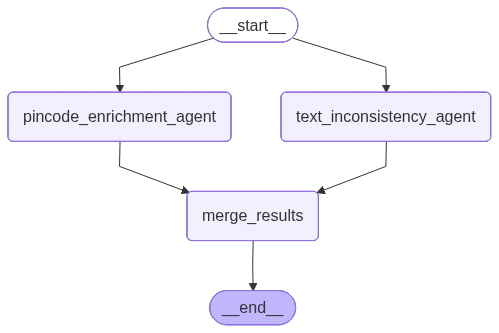

In [74]:
app

In [75]:
config = {"configurable": {"thread_id": "rupay_poc_batch_001"}}

# 1. Convert your source dataframe to a safe serializable list of records
serializable_data = df.to_dict(orient="records")

# 2. Build the initial graph state payload
initial_state = {
    "input_df": serializable_data
}

print("Launching LangGraph parallel agent orchestration...")

# 3. Fire the execution asynchronously
final_graph_state = await app.ainvoke(initial_state, config=config)


Launching LangGraph parallel agent orchestration...
--- STARTING: Lightning-Fast Local PIN Code Agent (Regionname Mode) ---
--- COMPLETED: Lightning-Fast Local PIN Code Agent (Regionname Mode) ---
--- STARTING: Future-Proof Gatekeeper Hybrid Text Agent ---
Total Unique Cities: 520
⚡ Bypassed LLM (Gatekeeper hit): 420
🤖 Anomalies Queued for LLM processing: 100
Slicing anomalies into 5 parallel chunks for fast processing...
--- COMPLETED: Future-Proof Gatekeeper Hybrid Text Agent ---
--- STARTING: Merge Results Node ---
--- COMPLETED: Merge Results Node (Data successfully aligned side-by-side) ---


In [76]:

# 4. Extract the processed records list from the final graph output state
records_cleansed = final_graph_state["final_df"]

# 5. Convert back into a Pandas DataFrame for complete tabular display
df_cleansed = pd.DataFrame(records_cleansed)

print("\n--- PoC EXECUTION COMPLETION ---")
# 6. Display the exact side-by-side layout you wanted to verify
df_cleansed[['city', 'corrected_city', 'pincode', 'fetched_pincode_city', 'fetched_pincode_state']].head(100)


--- PoC EXECUTION COMPLETION ---


,city,corrected_city,pincode,fetched_pincode_city,fetched_pincode_state
0,hyderabad,hyderabad,500084,hyderabad city region,telangana
1,Mum bai,mumbai,400070,mumbai region,maharashtra
2,PatnA,patna,800024,divreportingcircle,bihar
3,Coimb atore,coimbatore,641033,western region coimbatore,tamil nadu
4,Varanasi,varanasi,221018,pincode_not_found,pincode_not_found
...,...,...,...,...,...
95,Visakhapatnam,visakhapatnam,530018,visakhapatnam region,andhra pradesh
96,NashiK,nashik,422019,pincode_not_found,pincode_not_found
97,Noida,noida,201051,pincode_not_found,pincode_not_found
98,Aurangabad,aurangabad,431001,regional office aurangabad,maharashtra


In [77]:
# Print the step-by-step history execution trail of this specific thread
for state_snapshot in app.get_state_history(config):
    print(f"Checkpoint ID: {state_snapshot.config['configurable']['checkpoint_id']}")
    print(f"Next Node to Execute: {state_snapshot.next}")
    print(f"Values currently in buffer: {list(state_snapshot.values.keys())}")
    print("-" * 40)

Checkpoint ID: 1f153ac5-6297-6ab6-8002-34a8710f0b0b
Next Node to Execute: ()
Values currently in buffer: ['input_df', 'agent_outputs', 'final_df']
----------------------------------------
Checkpoint ID: 1f153ac5-61f5-6b2a-8001-4b98fc036e1b
Next Node to Execute: ('merge_results',)
Values currently in buffer: ['input_df', 'agent_outputs']
----------------------------------------
Checkpoint ID: 1f153ac4-40cc-6f07-8000-96ff2f7ba029
Next Node to Execute: ('text_inconsistency_agent', 'pincode_enrichment_agent')
Values currently in buffer: ['input_df', 'agent_outputs']
----------------------------------------
Checkpoint ID: 1f153ac4-40ac-6fb1-bfff-72b162b18960
Next Node to Execute: ('__start__',)
Values currently in buffer: ['agent_outputs']
----------------------------------------


In [79]:
df_cleansed.head()

,transaction_id,customer_id,customer_name,city,state,pincode,card_type,bank_name,account_type,transaction_amount,...,merchant_category,merchant_name,transaction_date,status,emi_flag,cashback_amount,reward_points,corrected_city,fetched_pincode_city,fetched_pincode_state
0,TXN000001,CUST1352,Varsha Trivedi,hyderabad,Telangana,500084,RuPay Kisan,Axis,Salary,39740.92,...,Clothing,Arrow,2024-04-10,Success,N,0.00,1191,hyderabad,hyderabad city region,telangana
1,TXN000002,CUST1402,Sushila Madan,Mum bai,Maharashtra,400070,RuPay Contactless,Union Bank,Savings,34104.93,...,Utilities,TATA Power,2023-03-25,Failed,N,0.00,0,mumbai,mumbai region,maharashtra
2,TXN000003,CUST1150,Jayesh Shah,PatnA,Bihar,800024,RuPay Millennia,PNB,Salary,6924.01,...,Grocery,Spar,2024-06-04,Success,N,0.00,69,patna,divreportingcircle,bihar
3,TXN000004,CUST1053,Suresh Taneja,Coimb atore,Tamil Nadu,641033,RuPay Platinum,City Union Bank,Salary,2929.42,...,Healthcare,PharmEasy,2023-09-30,Success,N,0.00,145,coimbatore,western region coimbatore,tamil nadu
4,TXN000005,CUST1117,Divya Tripathi,Varanasi,Uttar Pradesh,221018,RuPay Classic,Union Bank,Savings,12969.59,...,Healthcare,Max Hospital,2023-05-22,Success,N,76.52,258,varanasi,pincode_not_found,pincode_not_found


In [78]:
df_cleansed.to_dict(orient="records")

[{'transaction_id': 'TXN000001',
  'customer_id': 'CUST1352',
  'customer_name': 'Varsha Trivedi',
  'city': 'hyderabad',
  'state': 'Telangana',
  'pincode': 500084,
  'card_type': 'RuPay Kisan',
  'bank_name': 'Axis',
  'account_type': 'Salary',
  'transaction_amount': 39740.92,
  'transaction_type': 'Withdrawal',
  'merchant_category': 'Clothing',
  'merchant_name': 'Arrow',
  'transaction_date': '2024-04-10',
  'status': 'Success',
  'emi_flag': 'N',
  'cashback_amount': 0.0,
  'reward_points': 1191,
  'corrected_city': 'hyderabad',
  'fetched_pincode_city': 'hyderabad city region',
  'fetched_pincode_state': 'telangana'},
 {'transaction_id': 'TXN000002',
  'customer_id': 'CUST1402',
  'customer_name': 'Sushila Madan',
  'city': 'Mum bai',
  'state': 'Maharashtra',
  'pincode': 400070,
  'card_type': 'RuPay Contactless',
  'bank_name': 'Union Bank',
  'account_type': 'Savings',
  'transaction_amount': 34104.93,
  'transaction_type': 'Cashback',
  'merchant_category': 'Utilities',
 